# NB-03 — EDA Incidentes Atendidos por UAECOB (2016–2020)
## DataJam Bogotá 2026

**Objetivo:** Explorar los 5 archivos CSV de emergencias atendidas por bomberos (UAECOB), con énfasis en la distribución por localidad/UPZ, tipo de incidente, estrato y el análisis diferencial de género.

**Hipótesis:** Las localidades de estrato bajo concentran más incidentes de emergencia (incendios, emergencias ambientales) por habitante.

**Secciones:**
1. Lectura unificada con detección de encoding
2. Comparación de esquemas 2016 vs 2019
3. Distribución por tipo de servicio
4. Distribución espacial (Localidad, UPZ)
5. Distribución por estrato
6. Serie temporal (mensual/anual)
7. Análisis diferencial de género
8. Tabla de decisiones

In [1]:
import os
import chardet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
BRONZE = os.path.join(BASE, 'Bronze')

sns.set_theme(style='whitegrid', palette='muted')
print(f'Base: {BASE}')

ARCHIVOS_UAECOB = {
    2016: 'incidentes-atendidos-por-uaecob-2016.csv',
    2017: 'incidentes-atendidos-por-uaecob-2017-1.csv',
    2018: 'incidentes-atendidos-por-uaecob-2018.csv',
    2019: 'incidentes-atendidos-por-uaecob-2019.csv',
    2020: 'incidentes-atendidos-por-uaecob-corte-31-agosto-2020.csv'
}

Base: /home/naciscric/Documentos/DataJamBlackStar


## 1. Lectura Unificada con Detección de Encoding

In [2]:
def detectar_encoding(filepath):
    with open(filepath, 'rb') as f:
        raw = f.read(100000)
    res = chardet.detect(raw)
    return res.get('encoding', 'latin-1'), res.get('confidence', 0)

dfs_raw = {}

for year, fname in ARCHIVOS_UAECOB.items():
    fpath = os.path.join(BRONZE, fname)
    if not os.path.exists(fpath):
        print(f'⚠️ No encontrado: {fname}')
        continue
    
    enc, conf = detectar_encoding(fpath)
    size_mb = os.path.getsize(fpath) / 1024**2
    
    for enc_try in [enc, 'utf-8', 'latin-1', 'iso-8859-1']:
        try:
            df = pd.read_csv(fpath, sep=';', encoding=enc_try,
                             on_bad_lines='skip', low_memory=False)
            df['_año'] = year
            dfs_raw[year] = df
            print(f'✅ {year}: {fname}')
            print(f'   Encoding: {enc_try} (detect conf: {conf:.0%})')
            print(f'   Tamaño: {size_mb:.1f} MB | Filas: {len(df):,} | Columnas: {df.shape[1]}')
            print(f'   Columnas: {list(df.columns)[:6]}...\n')
            break
        except Exception as e:
            continue

✅ 2016: incidentes-atendidos-por-uaecob-2016.csv
   Encoding: Windows-1252 (detect conf: 1%)
   Tamaño: 7.3 MB | Filas: 36,971 | Columnas: 34
   Columnas: ['FECHA DEL EVENTO', 'ESTACION', 'BARRIO', 'ESTRATO', 'UPZ', 'LOCALIDAD']...



✅ 2017: incidentes-atendidos-por-uaecob-2017-1.csv
   Encoding: Windows-1252 (detect conf: 1%)
   Tamaño: 6.4 MB | Filas: 34,919 | Columnas: 34
   Columnas: ['FECHA DEL EVENTO', 'ESTACION', 'BARRIO', 'ESTRATO', 'UPZ', 'LOCALIDAD']...



✅ 2018: incidentes-atendidos-por-uaecob-2018.csv
   Encoding: Windows-1252 (detect conf: 1%)
   Tamaño: 7.8 MB | Filas: 36,961 | Columnas: 36
   Columnas: ['FECHA DEL EVENTO', 'NUMERO SERVICIO', 'ESTACION', 'BARRIO', 'ESTRATO', 'UPZ']...



✅ 2019: incidentes-atendidos-por-uaecob-2019.csv
   Encoding: Windows-1252 (detect conf: 1%)
   Tamaño: 9.5 MB | Filas: 37,898 | Columnas: 43
   Columnas: ['FECHA DEL EVENTO', 'NÚMERO SERVICIO', 'ESTACIÓN', 'LATITUD', 'LONGITUD', 'BARRIO']...

✅ 2020: incidentes-atendidos-por-uaecob-corte-31-agosto-2020.csv
   Encoding: Windows-1252 (detect conf: 1%)
   Tamaño: 5.0 MB | Filas: 20,228 | Columnas: 43
   Columnas: ['FECHA DEL EVENTO', 'NÚMERO SERVICIO', 'ESTACIÓN', 'LATITUD', 'LONGITUD', 'BARRIO']...



## 2. Comparación de Esquemas Entre Años

In [3]:
# Campos clave que buscamos en cada año
CAMPOS_OBJETIVO = {
    'fecha': ['fecha', 'date'],
    'localidad': ['localidad'],
    'upz': ['upz'],
    'estrato': ['estrato'],
    'servicio': ['servicio', 'clase de servicio'],
    'lat': ['latitud', 'lat'],
    'lon': ['longitud', 'lon'],
    'hombres_exp': ['hombres expuestos', 'pobla. expu.hombres', 'pobla. expu.hombres'],
    'mujeres_exp': ['mujeres expuestas', 'pobla. expu.mujeres'],
    'menores_exp': ['menores', 'ni\u00f1as', 'ni\u00f1os'],
}

def buscar_campo(columnas, opciones):
    cols_lower = [c.lower() for c in columnas]
    for opt in opciones:
        for i, c in enumerate(cols_lower):
            if opt in c:
                return columnas[i]
    return None

print('=== COMPARACIÓN DE ESQUEMAS POR AÑO ===\n')
mapeo_campos = {}

for year, df in dfs_raw.items():
    cols = list(df.columns)
    print(f'--- {year} ({len(df):,} registros) ---')
    encontrados = {}
    for campo, opciones in CAMPOS_OBJETIVO.items():
        col = buscar_campo(cols, opciones)
        encontrados[campo] = col
        status = f'✅ {col}' if col else '❌ NO ENCONTRADO'
        print(f'  {campo}: {status}')
    mapeo_campos[year] = encontrados
    print()

=== COMPARACIÓN DE ESQUEMAS POR AÑO ===

--- 2016 (36,971 registros) ---
  fecha: ✅ FECHA DEL EVENTO
  localidad: ✅ LOCALIDAD
  upz: ✅ UPZ
  estrato: ✅ ESTRATO
  servicio: ✅ SERVICIO
  lat: ❌ NO ENCONTRADO
  lon: ❌ NO ENCONTRADO
  hombres_exp: ✅ POBLA. EXPU.HOMBRES
  mujeres_exp: ✅ POBLA. EXPU.MUJERES
  menores_exp: ✅ POBLA. EXPU.MENORES

--- 2017 (34,919 registros) ---
  fecha: ✅ FECHA DEL EVENTO
  localidad: ✅ LOCALIDAD
  upz: ✅ UPZ
  estrato: ✅ ESTRATO
  servicio: ✅ SERVICIO
  lat: ❌ NO ENCONTRADO
  lon: ❌ NO ENCONTRADO
  hombres_exp: ✅ POBLA. EXPU.HOMBRES
  mujeres_exp: ✅ POBLA. EXPU.MUJERES
  menores_exp: ✅ POBLA. EXPU.MENORES

--- 2018 (36,961 registros) ---
  fecha: ✅ FECHA DEL EVENTO
  localidad: ✅ LOCALIDAD
  upz: ✅ UPZ
  estrato: ✅ ESTRATO
  servicio: ✅ NUMERO SERVICIO
  lat: ❌ NO ENCONTRADO
  lon: ❌ NO ENCONTRADO
  hombres_exp: ✅ HOMBRES EXPUESTOS
  mujeres_exp: ✅ MUJERES EXPUESTAS
  menores_exp: ✅ MENORES EXPUESTOS

--- 2019 (37,898 registros) ---
  fecha: ✅ FECHA DEL EVENT

## 3. Distribución por Tipo de Servicio

In [4]:
def clasificar_incidente(servicio):
    """Clasifica el tipo de incidente en categorías simplificadas."""
    if pd.isna(servicio):
        return 'SIN CLASIFICAR'
    s = str(servicio).upper()
    if '1. INCENDIO' in s or 'INCENDIO' in s:
        return 'INCENDIO'
    if 'EMERGENCIA' in s:
        return 'EMERGENCIA'
    if 'FALSA' in s or 'QUEMA' in s:
        return 'FALSA_ALARMA_QUEMA'
    if 'RESCATE' in s or 'SALVAMENTO' in s:
        return 'RESCATE'
    if 'ACCIDENTE' in s or 'VEHICULO' in s or 'TR\u00c1NSITO' in s:
        return 'ACCIDENTE_TRANSITO'
    if 'MATERIALES' in s or 'QUIMICO' in s or 'HAZMATO' in s:
        return 'MATERIALES_PELIGROSOS'
    return 'OTRO'

# Combinar todos los años con campo de servicio normalizado
frames_tipo = []
for year, df in dfs_raw.items():
    col_serv = mapeo_campos[year].get('servicio')
    col_localidad = mapeo_campos[year].get('localidad')
    col_estrato = mapeo_campos[year].get('estrato')
    
    if col_serv:
        df_temp = pd.DataFrame()
        df_temp['servicio_raw'] = df[col_serv].astype(str)
        df_temp['tipo_incidente'] = df_temp['servicio_raw'].apply(clasificar_incidente)
        df_temp['año'] = year
        if col_localidad:
            df_temp['localidad'] = df[col_localidad].astype(str).str.upper().str.strip()
        if col_estrato:
            df_temp['estrato'] = pd.to_numeric(df[col_estrato], errors='coerce')
        frames_tipo.append(df_temp)

df_incidentes = pd.concat(frames_tipo, ignore_index=True)
print(f'Total incidentes combinados: {len(df_incidentes):,}')
print('\nDistribución por tipo:')
tipo_dist = df_incidentes['tipo_incidente'].value_counts()
print(tipo_dist)

Total incidentes combinados: 166,977

Distribución por tipo:
tipo_incidente
OTRO                  119358
INCENDIO               36525
FALSA_ALARMA_QUEMA      6250
ACCIDENTE_TRANSITO      3481
RESCATE                 1363
Name: count, dtype: int64


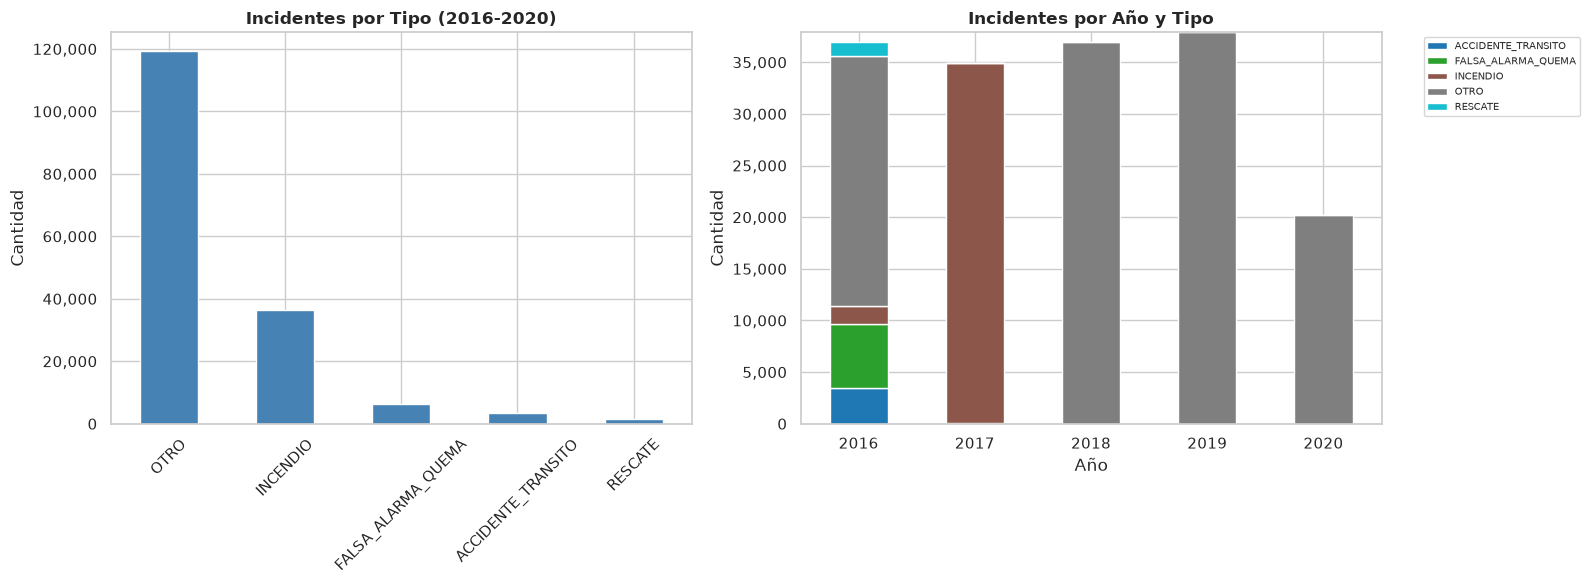

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total por tipo
tipo_dist.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Incidentes por Tipo (2016-2020)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Por año
por_año_tipo = df_incidentes.groupby(['año', 'tipo_incidente']).size().unstack(fill_value=0)
por_año_tipo.plot(kind='bar', ax=axes[1], stacked=True, colormap='tab10', edgecolor='white')
axes[1].set_title('Incidentes por Año y Tipo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right', fontsize=7, bbox_to_anchor=(1.35, 1))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../outputs/03_incidentes_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribución Espacial por Localidad

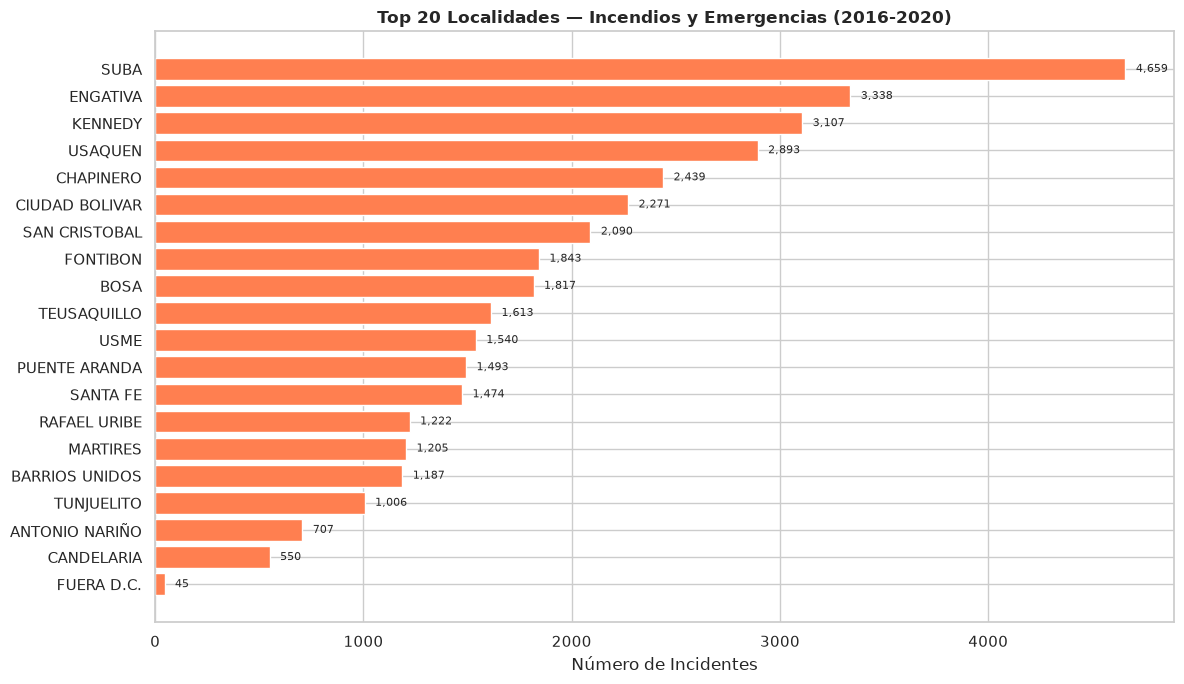

In [6]:
if 'localidad' in df_incidentes.columns:
    # Filtrar solo incendios + emergencias (más relevantes para hipótesis)
    df_relevantes = df_incidentes[df_incidentes['tipo_incidente'].isin(['INCENDIO', 'EMERGENCIA'])].copy()
    
    loc_counts = df_relevantes['localidad'].value_counts().head(20)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    bars = ax.barh(loc_counts.index[::-1], loc_counts.values[::-1],
                   color='coral', edgecolor='white')
    ax.set_title('Top 20 Localidades — Incendios y Emergencias (2016-2020)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Número de Incidentes')
    for bar in bars:
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{int(bar.get_width()):,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('../outputs/03_incidentes_por_localidad.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Columna de localidad no disponible en dataset combinado')

## 5. Distribución por Estrato — Hipótesis Central

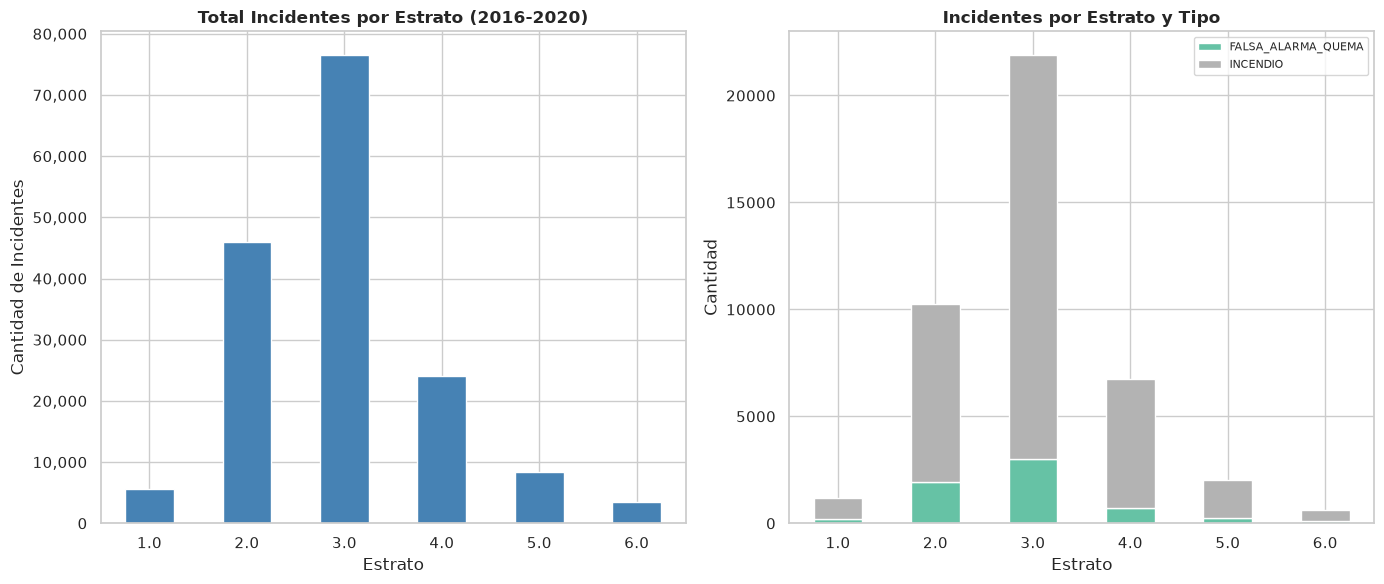


=== HALLAZGO CLAVE — Hipótesis ===
estrato
1.0     5625
2.0    45964
3.0    76575
4.0    24049
5.0     8314
6.0     3413
Name: tipo_incidente, dtype: int64

Porcentaje por estrato:
estrato
1.0     3.4
2.0    28.0
3.0    46.7
4.0    14.7
5.0     5.1
6.0     2.1
Name: tipo_incidente, dtype: float64


In [7]:
if 'estrato' in df_incidentes.columns:
    df_estrato = df_incidentes[df_incidentes['estrato'].between(1, 6)].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Conteo total por estrato
    est_counts = df_estrato.groupby('estrato')['tipo_incidente'].count()
    est_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Total Incidentes por Estrato (2016-2020)',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Estrato')
    axes[0].set_ylabel('Cantidad de Incidentes')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    
    # Distribución por tipo e incidente
    est_tipo = df_estrato[df_estrato['tipo_incidente'].isin(['INCENDIO','EMERGENCIA','FALSA_ALARMA_QUEMA'])]
    est_tipo_pivot = est_tipo.groupby(['estrato','tipo_incidente']).size().unstack(fill_value=0)
    est_tipo_pivot.plot(kind='bar', ax=axes[1], stacked=True,
                        colormap='Set2', edgecolor='white')
    axes[1].set_title('Incidentes por Estrato y Tipo',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Estrato')
    axes[1].set_ylabel('Cantidad')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig('../outputs/03_incidentes_por_estrato.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('\n=== HALLAZGO CLAVE — Hipótesis ===')
    print(df_estrato.groupby('estrato')['tipo_incidente'].count())
    print('\nPorcentaje por estrato:')
    print((df_estrato.groupby('estrato')['tipo_incidente'].count() / len(df_estrato) * 100).round(1))
else:
    print('Columna de estrato no disponible — se asignará por join espacial con Esoc.csv en Silver')

## 6. Serie Temporal Mensual

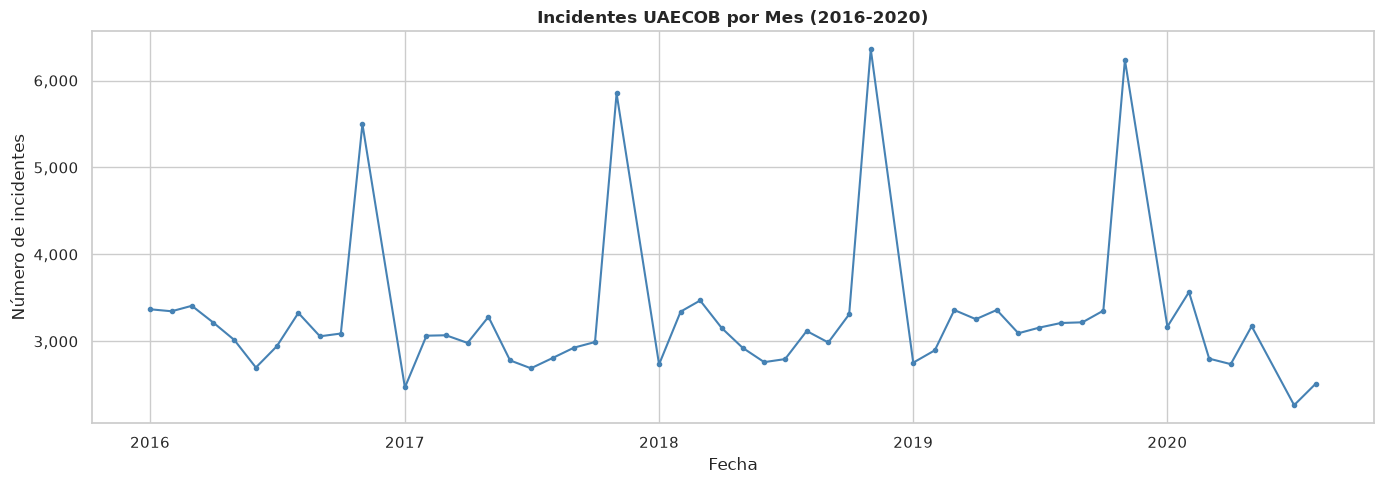

In [8]:
# Construir serie temporal combinando columna de fecha por año
frames_fecha = []
for year, df in dfs_raw.items():
    col_fecha = mapeo_campos[year].get('fecha')
    col_serv = mapeo_campos[year].get('servicio')
    if col_fecha:
        try:
            df_temp = df[[col_fecha]].copy()
            if col_serv:
                df_temp['tipo_incidente'] = df[col_serv].apply(clasificar_incidente)
            else:
                df_temp['tipo_incidente'] = 'SIN CLASIFICAR'
            df_temp.columns = ['fecha_raw', 'tipo_incidente']
            df_temp['año'] = year
            frames_fecha.append(df_temp)
        except Exception as e:
            print(f'Error procesando fechas {year}: {e}')

if frames_fecha:
    df_fechas = pd.concat(frames_fecha, ignore_index=True)
    # Extraer mes del texto de fecha (ej: 'viernes 1 de enero de 2016')
    MESES_ES = {
        'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
        'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':11
    }
    def extraer_mes(fecha_str):
        if pd.isna(fecha_str): return None
        s = str(fecha_str).lower()
        for mes, num in MESES_ES.items():
            if mes in s: return num
        return None
    
    df_fechas['mes'] = df_fechas['fecha_raw'].apply(extraer_mes)
    df_fechas = df_fechas.dropna(subset=['mes'])
    df_fechas['mes'] = df_fechas['mes'].astype(int)
    
    serie_mensual = df_fechas.groupby(['año','mes']).size().reset_index(name='n_incidentes')
    serie_mensual['fecha'] = pd.to_datetime(
        serie_mensual.apply(lambda r: f"{r['año']}-{r['mes']:02d}-01", axis=1)
    )
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(serie_mensual['fecha'], serie_mensual['n_incidentes'],
            marker='o', linewidth=1.5, color='steelblue', markersize=3)
    ax.set_title('Incidentes UAECOB por Mes (2016-2020)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Número de incidentes')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig('../outputs/03_serie_temporal_incidentes.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Análisis Diferencial de Género

=== ANÁLISIS DIFERENCIAL DE GÉNERO ===
 año  hombres_exp  mujeres_exp  niñas_exp  niños_exp
2016      38392.0       5620.0        NaN     7766.0
2017      12265.0       6424.0        NaN     4154.0
2018      10966.0       5511.0        NaN        NaN
2019      13330.0       7504.0     1832.0     2876.0
2020       2691.0       1658.0      327.0      423.0


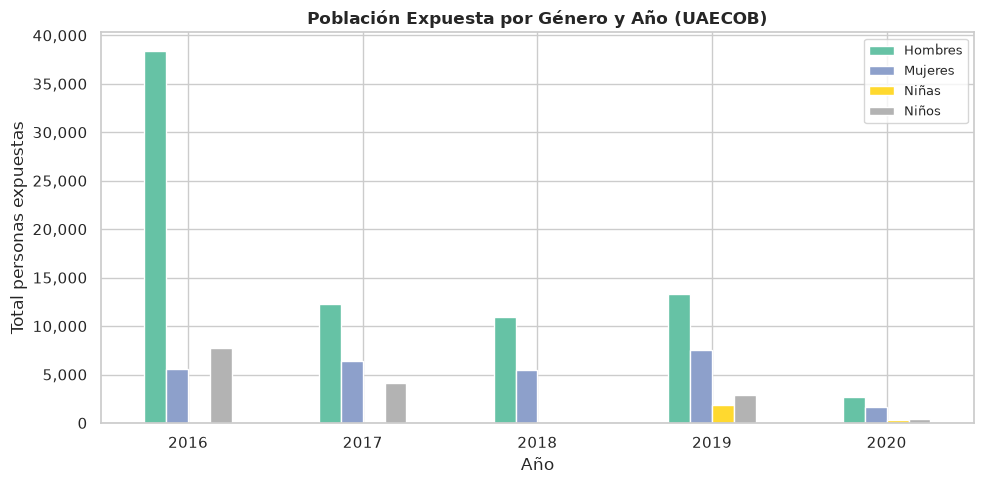

In [9]:
genero_data = []

for year, df in dfs_raw.items():
    cols = list(df.columns)
    cols_lower = [c.lower() for c in cols]
    
    def encontrar_col(terminos):
        for t in terminos:
            for i, c in enumerate(cols_lower):
                if t in c: return cols[i]
        return None
    
    col_h = encontrar_col(['hombres expuestos','pobla. expu.hombres'])
    col_m = encontrar_col(['mujeres expuestas','pobla. expu.mujeres'])
    col_mn = encontrar_col(['menores ni\u00f1as expuestas','menores expuesta'])
    col_mno = encontrar_col(['menores ni\u00f1os expuestos', 'pobla. expu.menores'])
    
    row_genero = {'año': year}
    for nombre, col in [('hombres_exp', col_h), ('mujeres_exp', col_m),
                         ('niñas_exp', col_mn), ('niños_exp', col_mno)]:
        if col:
            row_genero[nombre] = pd.to_numeric(df[col], errors='coerce').sum()
        else:
            row_genero[nombre] = np.nan
    genero_data.append(row_genero)

genero_df = pd.DataFrame(genero_data)
print('=== ANÁLISIS DIFERENCIAL DE GÉNERO ===')
print(genero_df.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
genero_plot = genero_df.set_index('año')[['hombres_exp','mujeres_exp','niñas_exp','niños_exp']].fillna(0)
genero_plot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Población Expuesta por Género y Año (UAECOB)', fontsize=12, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Total personas expuestas')
ax.tick_params(axis='x', rotation=0)
ax.legend(['Hombres','Mujeres','Niñas','Niños'], fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../outputs/03_diferencial_genero.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Tabla de Decisiones

In [10]:
decisiones = []
for year, df in dfs_raw.items():
    tiene_geo = mapeo_campos[year].get('lat') is not None
    tiene_localidad = mapeo_campos[year].get('localidad') is not None
    tiene_estrato = mapeo_campos[year].get('estrato') is not None
    tiene_genero = mapeo_campos[year].get('hombres_exp') is not None
    n_registros = len(df)
    
    if tiene_geo:
        decision = '✅ USAR (geolocalizado)'
    elif tiene_localidad:
        decision = '✅ USAR (join por texto)'
    else:
        decision = '⚠️ EVALUAR — join espacial requerido'
    
    decisiones.append({
        'año': year,
        'n_registros': n_registros,
        'tiene_lat_lon': '✅' if tiene_geo else '❌',
        'tiene_localidad': '✅' if tiene_localidad else '❌',
        'tiene_estrato': '✅' if tiene_estrato else '❌',
        'tiene_género': '✅' if tiene_genero else '❌',
        'decisión': decision
    })

dec_df = pd.DataFrame(decisiones)
print('=== TABLA DE DECISIONES — INCIDENTES UAECOB ===')
print(dec_df.to_string(index=False))

dec_df.to_csv('../Silver/decisiones_incidentes.csv', index=False)
print('\n✅ NB-03 completado. Guardado en Silver/decisiones_incidentes.csv')

=== TABLA DE DECISIONES — INCIDENTES UAECOB ===
 año  n_registros tiene_lat_lon tiene_localidad tiene_estrato tiene_género                decisión
2016        36971             ❌               ✅             ✅            ✅ ✅ USAR (join por texto)
2017        34919             ❌               ✅             ✅            ✅ ✅ USAR (join por texto)
2018        36961             ❌               ✅             ✅            ✅ ✅ USAR (join por texto)
2019        37898             ✅               ✅             ✅            ✅  ✅ USAR (geolocalizado)
2020        20228             ✅               ✅             ✅            ✅  ✅ USAR (geolocalizado)

✅ NB-03 completado. Guardado en Silver/decisiones_incidentes.csv
